## Part 1: Imports and Setup

Import the required libraries for this project.

In [30]:
# Import standard library modules needed throughout the project
import csv          # for reading the CSV dataset
import heapq        # for heap-based top-K operations
import re           # for regex-based suspicious pattern matching

from collections import deque          # efficient O(1) queue for BFS
from typing import Dict, List, Set     # type hints for clarity

# Third-party visualisation libraries (install with: pip install networkx matplotlib scipy)
import networkx as nx
import matplotlib.pyplot as plt

## Part 2: Data Loading

Implement a function to load CSV data into a list of dictionaries.

In [31]:
def load_data(file_path: str) -> List[Dict[str, str]]:
    """Load transaction records from a CSV file.

    Parameters
    ----------
    file_path : str
        Path to the CSV file to read.

    Returns
    -------
    List[Dict[str, str]]
        Each element is one row from the CSV, keyed by column header.

    Time complexity: O(N) where N = number of rows in the CSV.
    Space complexity: O(N) to store all transaction records in memory.
    """
    transactions: List[Dict[str, str]] = []

    # Open the file with UTF-8 encoding; newline='' prevents double line-endings
    with open(file_path, newline='', encoding='utf-8') as csv_file:
        # DictReader automatically uses the first row as field names
        reader = csv.DictReader(csv_file)
        for row in reader:
            transactions.append(dict(row))   # convert OrderedDict -> plain dict

    return transactions

## Part 3: Graph Construction

Build a graph where users are connected to products they purchased.

In [32]:
def build_graph(data: List[Dict[str, str]]) -> Dict[str, Set[str]]:
    """Build an undirected bipartite adjacency-list graph from transaction records.

    Each user node is connected to the product nodes it purchased, and each
    product node links back to the users that bought it.  Storing edges in
    both directions lets BFS traverse the full connected component from any
    starting node (user *or* product).

    Parameters
    ----------
    data : List[Dict[str, str]]
        Loaded transaction records (output of load_data).

    Returns
    -------
    Dict[str, Set[str]]
        Adjacency list: node -> set of neighbouring nodes.

    Time complexity: O(N) where N = number of transactions -- one pass to
                     build both directions of each edge.
    Space complexity: O(V + E) where V = unique users + products,
                      E = unique (user, product) pairs.
    """
    graph: Dict[str, Set[str]] = {}

    for transaction in data:
        user_id    = transaction['user_id']
        product_id = transaction['product_id']

        # Add product to user's neighbour set
        # Set default is like default dict callable on individual elements of the dict
        graph.setdefault(user_id, set()).add(product_id)

        # Add user to product's neighbour set (undirected edge -- required for BFS)
        graph.setdefault(product_id, set()).add(user_id)

    return graph

## Part 4: Graph Traversal (BFS)

Implement Breadth-First Search to traverse the graph.

In [33]:
def bfs(graph: Dict[str, Set[str]], start: str) -> Set[str]:
    """Breadth-First Search from a starting node.

    Explores the graph layer by layer using a FIFO queue (deque).
    Time complexity: O(V + E) where V = nodes visited, E = edges traversed.

    Parameters
    ----------
    graph : Dict[str, Set[str]]
        Adjacency list representation of the graph.
    start : str
        Node from which to begin traversal.

    Returns
    -------
    Set[str]
        All nodes reachable from 'start' (including start itself).
    """
    visited: Set[str] = set()
    queue: deque = deque([start])   # initialise the queue with the start node

    while queue:
        node = queue.popleft()      # dequeue the front node -- O(1) with deque

        if node not in visited:
            visited.add(node)       # mark as visited so we don't revisit it

            # Enqueue all unvisited neighbours
            for neighbor in graph.get(node, set()):
                queue.append(neighbor)

    return visited

## Part 5: Pattern Matching (Regex)

Find suspicious transactions by searching for suspicious keywords.

In [34]:
def find_suspicious(data: List[Dict[str, str]], keywords: List[str]) -> List[Dict[str, str]]:
    """Return transactions whose description field contains any suspicious keyword.

    The keywords are joined into a single alternation pattern (kw1|kw2|...)
    which is compiled once for efficiency, then matched case-insensitively
    against each transaction's 'description' field.

    Time complexity: O(N * L) where N = number of transactions,
                                      L = average description length.

    Parameters
    ----------
    data     : List[Dict[str, str]]  Transaction records to search.
    keywords : List[str]             Suspicious words (e.g. ['urgent','lottery','refund']).

    Returns
    -------
    List[Dict[str, str]]
        Subset of 'data' whose description matched at least one keyword.
    """
    # Build one compiled pattern from all keywords (avoids re-compiling per row)
    pattern = re.compile('|'.join(keywords), re.IGNORECASE)

    return [txn for txn in data if pattern.search(txn['description'])]

## Part 6: Top-K Products (Heap)

Use a heap to efficiently find the top-K most purchased products.

In [35]:
def top_k_products(data: List[Dict[str, str]], k: int) -> List[str]:
    """Return the k most frequently purchased product IDs.

    Counts purchases with a hash map (O(N)), then uses heapq.nlargest to
    extract the top-k entries in O(N log k) -- much faster than a full sort
    when k << N.

    Parameters
    ----------
    data : List[Dict[str, str]]  Transaction records.
    k    : int                   Number of top products to return.

    Returns
    -------
    List[str]
        Product IDs sorted from most to least purchased (length <= k).
    """
    # Count how many times each product appears across all transactions
    freq: Dict[str, int] = {}
    for txn in data:
        pid = txn['product_id']
        freq[pid] = freq.get(pid, 0) + 1

    # heapq.nlargest selects the top-k items by frequency in O(N log k)
    # The lambda makes sure to extract the count portion of the key
    # value pairs.
    top_items = heapq.nlargest(k, freq.items(), key=lambda item: item[1])

    # Return only the product IDs, not the raw counts
    return [product for product, _count in top_items]

## Part 7: Load Data

Load the dataset for analysis.

In [36]:
# Load all transaction records from the notional dataset CSV file
dataset = load_data('notional_dataset.csv')

# Quick sanity check -- confirm data loaded and inspect one record
print(f"Loaded {len(dataset)} transactions.")
print("\nSample transaction (first row):")
print(dataset[0])

Loaded 992 transactions.

Sample transaction (first row):
{'transaction_id': 'T000017', 'user_id': 'U0119', 'timestamp': '2023-04-15 01:04:00', 'description': 'payment', 'amount': '1796.38', 'product_id': 'P0058'}


## Part 8: Exploratory Data Analysis

Analyze the dataset to understand its structure.

DATASET OVERVIEW

Total transactions: 992

Sample transaction:
  {'transaction_id': 'T000017', 'user_id': 'U0119', 'timestamp': '2023-04-15 01:04:00', 'description': 'payment', 'amount': '1796.38', 'product_id': 'P0058'}

Unique users:        420
Unique products:     200
Unique descriptions: 22

Base transaction type distribution:
  donation                264  (26.6%)
  purchase                255  (25.7%)
  subscription            239  (24.1%)
  payment                 234  (23.6%)

Amount statistics:
  Min:     $      8.39
  Max:     $  21921.79
  Average: $   2888.93

Suspicious transactions: 37 (3.73%)


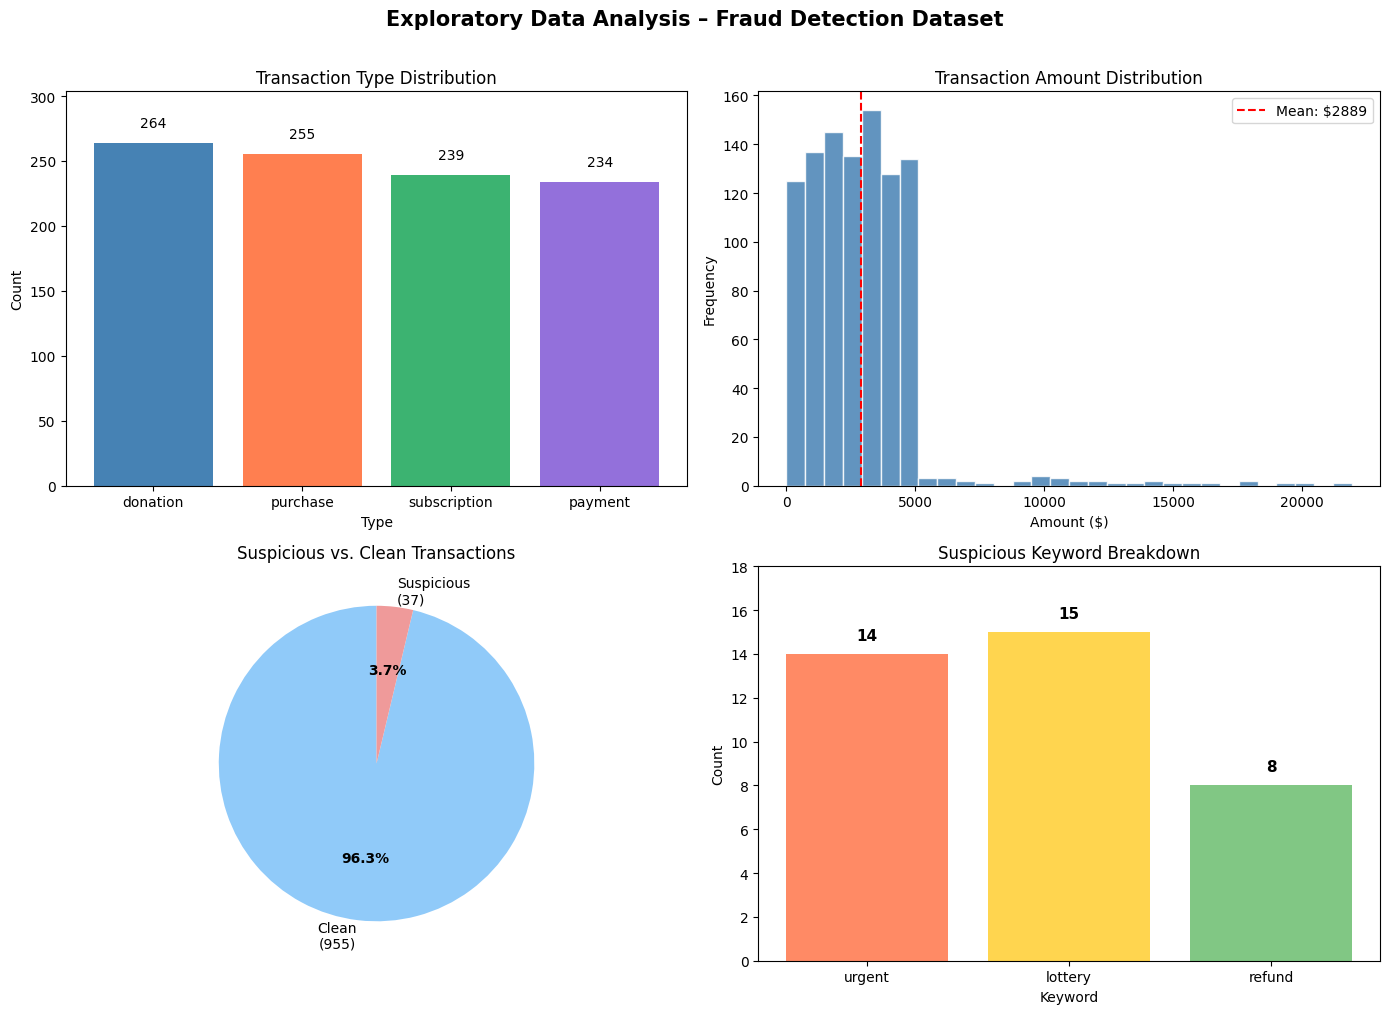

In [37]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

# 1. Total number of transactions
total_transactions = len(dataset)
print(f"\nTotal transactions: {total_transactions}")

# 2. Sample transaction
print(f"\nSample transaction:\n  {dataset[0]}")

# 3. Count unique users, products, and description types
# Set comprehensions "[]"" deduplicate IDs in a single O(N) pass
unique_users        = {txn['user_id']     for txn in dataset}
unique_products     = {txn['product_id']  for txn in dataset}
unique_descriptions = {txn['description'] for txn in dataset}

print(f"\nUnique users:        {len(unique_users)}")
print(f"Unique products:     {len(unique_products)}")
print(f"Unique descriptions: {len(unique_descriptions)}")

# 4. Transaction type distribution
# Group descriptions by their base type (first word) for clarity
base_type_counts: Dict[str, int] = {}
for txn in dataset:
    base = txn['description'].split()[0]   # e.g. "donation urgent" -> "donation"
    base_type_counts[base] = base_type_counts.get(base, 0) + 1

print("\nBase transaction type distribution:")
for desc, count in sorted(base_type_counts.items(), key=lambda x: -x[1]):
    pct = count / total_transactions * 100
    print(f"  {desc:<20} {count:>6}  ({pct:.1f}%)")

# 5. Amount statistics -- amounts are stored as strings, so cast to float
amounts = [float(txn['amount']) for txn in dataset]

print(f"\nAmount statistics:")
print(f"  Min:     ${min(amounts):>10.2f}")
print(f"  Max:     ${max(amounts):>10.2f}")
print(f"  Average: ${sum(amounts) / len(amounts):>10.2f}")

# 6 & 7. Suspicious transaction count and rate
suspicious_keywords = ["urgent", "lottery", "refund"]

suspicious_txns  = find_suspicious(dataset, suspicious_keywords)
suspicious_count = len(suspicious_txns)
suspicious_rate  = suspicious_count / total_transactions * 100

print(f"\nSuspicious transactions: {suspicious_count} ({suspicious_rate:.2f}%)")

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis – Fraud Detection Dataset",
             fontsize=15, fontweight='bold', y=1.01)

# -- Chart 1: Transaction type distribution (bar) ----------------------------
ax1 = axes[0, 0]
types_sorted = sorted(base_type_counts.items(), key=lambda x: -x[1])
labels1, values1 = zip(*types_sorted)
bars = ax1.bar(labels1, values1, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
ax1.set_title("Transaction Type Distribution")
ax1.set_xlabel("Type")
ax1.set_ylabel("Count")
# Annotate each bar with its count
for bar, val in zip(bars, values1):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10)
ax1.set_ylim(0, max(values1) * 1.15)

# -- Chart 2: Transaction amount histogram -----------------------------------
ax2 = axes[0, 1]
ax2.hist(amounts, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(sum(amounts) / len(amounts), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean: ${sum(amounts)/len(amounts):.0f}")
ax2.set_title("Transaction Amount Distribution")
ax2.set_xlabel("Amount ($)")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=10)

# -- Chart 3: Suspicious vs. clean pie chart ---------------------------------
ax3 = axes[1, 0]
clean_count = total_transactions - suspicious_count
pie_vals    = [clean_count, suspicious_count]
pie_labels  = [f"Clean\n({clean_count:,})", f"Suspicious\n({suspicious_count:,})"]
pie_colors  = ['#90CAF9', '#EF9A9A']
wedges, texts, autotexts = ax3.pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax3.set_title("Suspicious vs. Clean Transactions")

# -- Chart 4: Suspicious keyword breakdown (bar) -----------------------------
ax4 = axes[1, 1]
kw_counts = {}
for kw in suspicious_keywords:
    # Count transactions whose description contains this specific keyword
    kw_counts[kw] = sum(1 for txn in dataset if kw.lower() in txn['description'].lower())

kw_colors = ['#FF8A65', '#FFD54F', '#81C784']
kw_bars = ax4.bar(kw_counts.keys(), kw_counts.values(), color=kw_colors)
ax4.set_title("Suspicious Keyword Breakdown")
ax4.set_xlabel("Keyword")
ax4.set_ylabel("Count")
for bar, val in zip(kw_bars, kw_counts.values()):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_ylim(0, max(kw_counts.values()) * 1.2)

plt.tight_layout()
plt.show()

## Part 9: Build and Display Graph

Create the user-product graph and print its structure.

In [38]:
# Build the adjacency-list graph from the loaded dataset.
# Each user node connects to every product it purchased (and vice-versa)
# so that BFS can traverse the full component from any starting node.
graph = build_graph(dataset)

# Print a small sample rather than the entire graph to keep output readable
print("User-Product Graph (first 5 nodes shown):")
for node, neighbors in list(graph.items())[:5]:
    print(f"  {node}: {neighbors}")

print(f"\n  ... ({len(graph)} total nodes across users and products)")

User-Product Graph (first 5 nodes shown):
  U0119: {'P0058'}
  P0058: {'U0119', 'U0147', 'U0185', 'U0186', 'U0166', 'U0101'}
  U0362: {'P0146', 'P0134'}
  P0134: {'U0350', 'U0384', 'U0365', 'U0308', 'U0372', 'U0353', 'U0351', 'U0362'}
  U0074: {'P0007', 'P0017'}

  ... (620 total nodes across users and products)


## Part 10: Visualize Graph with NetworkX

Create a visual representation of the user-product network.

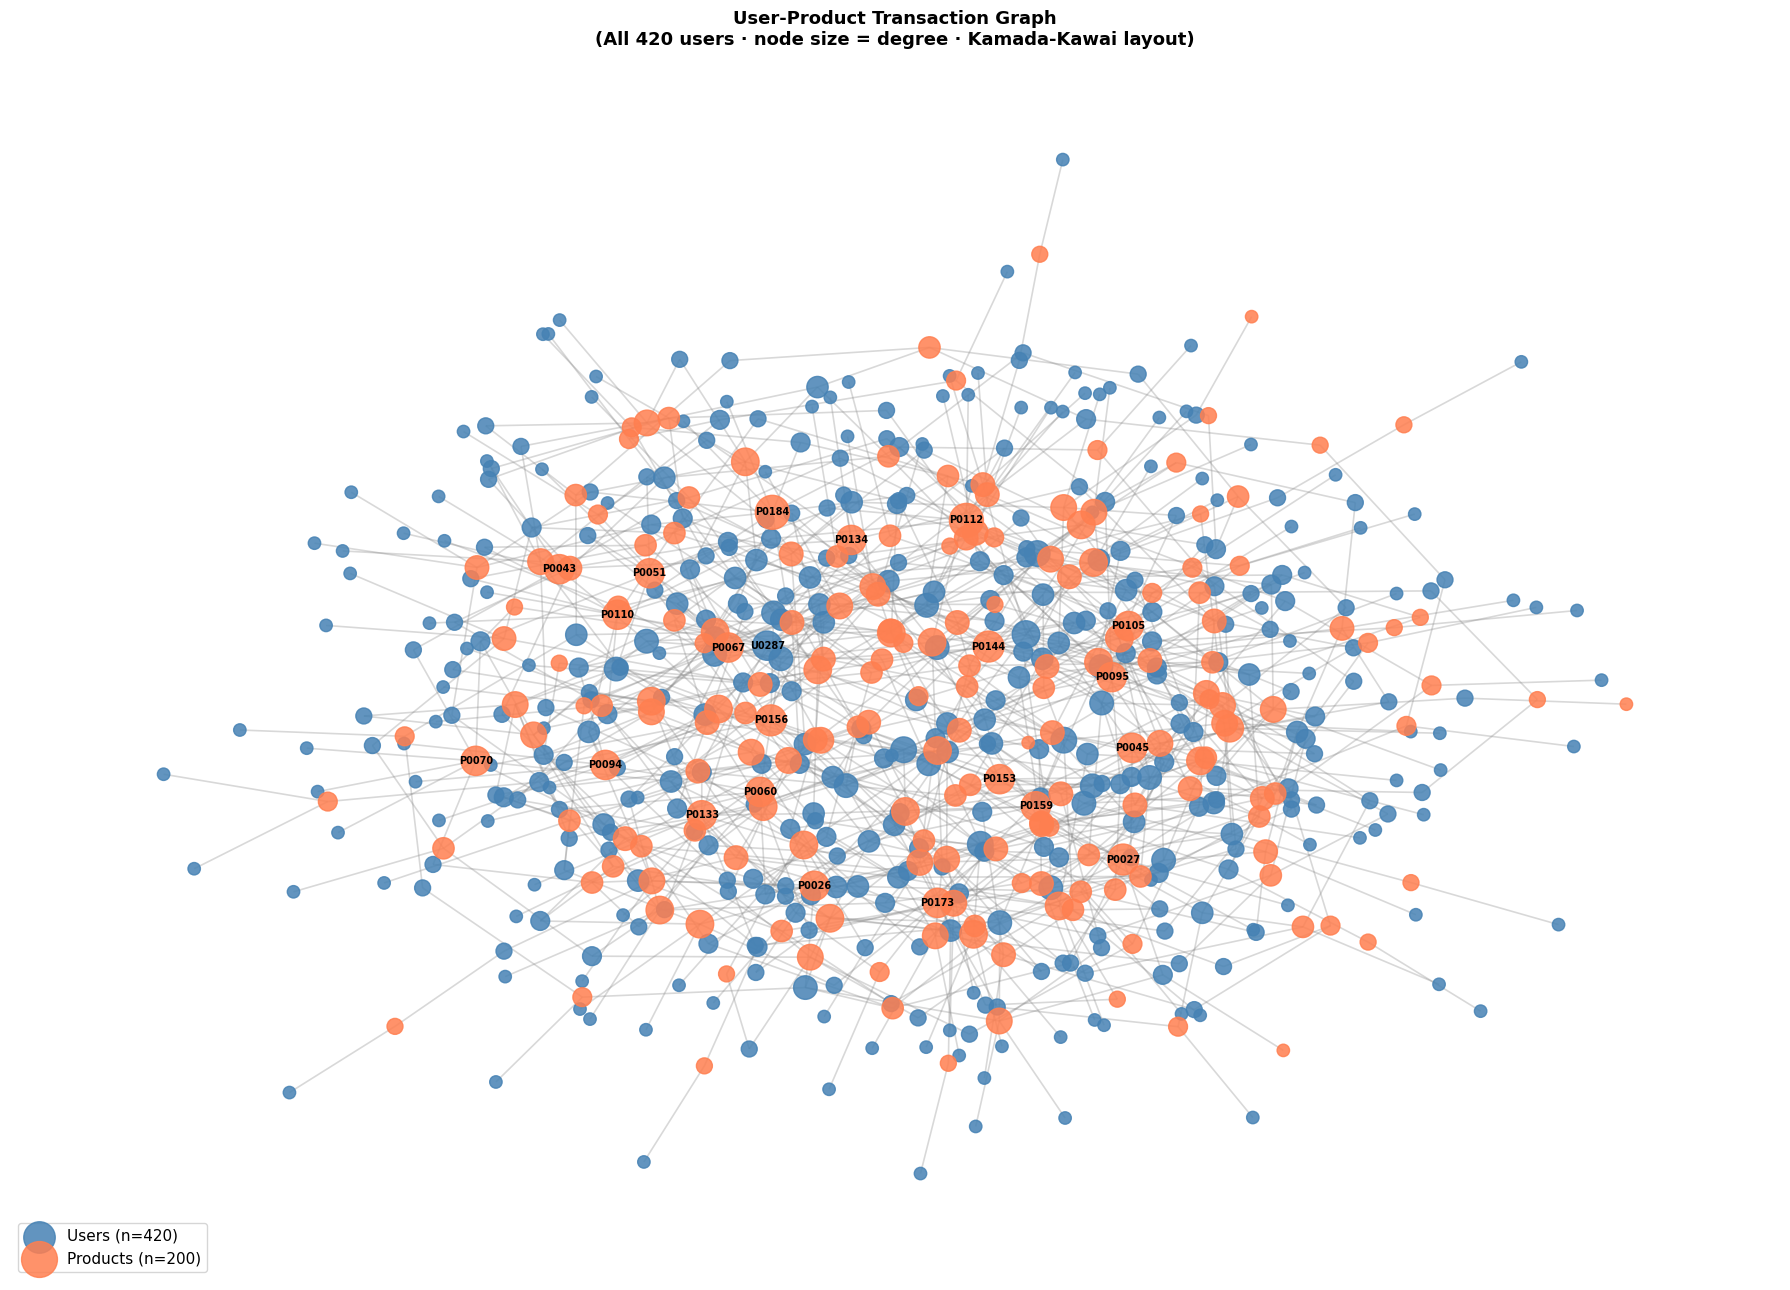


Graph Statistics:
  Nodes : 620  (420 users, 200 products)
  Edges : 969
  Avg degree : 3.13


In [39]:
# Visualize the full user-product graph using NetworkX
# Layout choices for 700 nodes:
#   1. Kamada-Kawai -- spreads nodes evenly; seeded with bipartite hint
#   2. Node size scaled by degree (more connections = bigger node)
#   3. Thin edges (low alpha) to reduce visual clutter

import scipy

# -- Step 1: Build a NetworkX graph from the full dataset --------------------
G = nx.Graph()
for txn in dataset:
    G.add_edge(txn['user_id'], txn['product_id'])

# -- Step 2: Separate users and products for coloring -----------------------
all_nodes     = list(G.nodes())
users_in_G    = [n for n in all_nodes if n.startswith('U')]
products_in_G = [n for n in all_nodes if n.startswith('P')]

# -- Step 3: Kamada-Kawai layout with a bipartite initial hint ---------------
# Seed positions so users start on the left, products on the right.
initial_pos = {}
for i, u in enumerate(users_in_G):
    initial_pos[u] = (-1.0, i / max(len(users_in_G) - 1, 1) * 2 - 1)
for i, p in enumerate(products_in_G):
    initial_pos[p] = (1.0,  i / max(len(products_in_G) - 1, 1) * 2 - 1)

pos = nx.kamada_kawai_layout(G, pos=initial_pos, weight=None)

# -- Step 4: Scale node sizes by degree (connections) -----------------------
degrees = dict(G.degree())
min_deg, max_deg = min(degrees.values()), max(degrees.values())
deg_range = max(max_deg - min_deg, 1)

def node_size(node):
    return 80 + ((degrees[node] - min_deg) / deg_range) * 520

user_sizes    = [node_size(n) for n in users_in_G]
product_sizes = [node_size(n) for n in products_in_G]

# -- Step 5: Draw the graph --------------------------------------------------
plt.figure(figsize=(18, 13))

nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.2, edge_color='grey')

# Users -- blue
nx.draw_networkx_nodes(G, pos, nodelist=users_in_G,
                       node_color='steelblue', node_size=user_sizes,
                       alpha=0.85, label=f'Users (n={len(users_in_G)})')

# Products -- coral
nx.draw_networkx_nodes(G, pos, nodelist=products_in_G,
                       node_color='coral', node_size=product_sizes,
                       alpha=0.85, label=f'Products (n={len(products_in_G)})')

# Label only the highest-degree nodes to avoid overlap
degree_threshold = sorted(degrees.values(), reverse=True)[min(15, len(degrees)-1)]
labels_to_show = {n: n for n, d in degrees.items() if d >= degree_threshold}
nx.draw_networkx_labels(G, pos, labels=labels_to_show,
                        font_size=7, font_color='black', font_weight='bold')

plt.title(
    f'User-Product Transaction Graph\n'
    f'(All {len(users_in_G)} users · node size = degree · Kamada-Kawai layout)',
    fontsize=13, fontweight='bold'
)
plt.legend(scatterpoints=1, fontsize=11, loc='lower left',
           framealpha=0.8, markerscale=1.4)
plt.axis('off')
plt.tight_layout()
plt.show()

# -- Step 6: Print graph statistics ------------------------------------------
print(f"\nGraph Statistics:")
print(f"  Nodes : {G.number_of_nodes()}  "
      f"({len(users_in_G)} users, {len(products_in_G)} products)")
print(f"  Edges : {G.number_of_edges()}")
avg_deg = sum(degrees.values()) / G.number_of_nodes()
print(f"  Avg degree : {avg_deg:.2f}")

## Part 11: Connected Components Detection

Find all connected components in the graph.

In [40]:
def detect_connected_components(graph: Dict[str, Set[str]]) -> List[Set[str]]:
    """Find every connected component in the graph using BFS.

    A connected component is a maximal set of nodes where every node can
    reach every other node.  We iterate over all graph nodes and call bfs()
    on each unvisited one; when BFS finishes it has discovered one full
    component.

    Time complexity: O(V + E) -- each node and edge is visited exactly once.

    Parameters
    ----------
    graph : Dict[str, Set[str]]
        Adjacency list (output of build_graph).

    Returns
    -------
    List[Set[str]]
        List of sets, where each set contains the nodes of one component.
    """
    visited: Set[str] = set()       # nodes already assigned to a component
    components: List[Set[str]] = []

    for node in graph:
        if node not in visited:
            # BFS discovers every node reachable from this unvisited node
            component = bfs(graph, node)
            components.append(component)
            # Mark the entire component as visited to skip it in future iterations
            visited.update(component)

    return components


# ── Analyse results ──────────────────────────────────────────────────────────
components = detect_connected_components(graph)

print(f"Total connected components: {len(components)}")

# Sort by size descending so the most connected clusters appear first
components_sorted = sorted(components, key=len, reverse=True)

print("\nTop 10 components by size:")
for i, comp in enumerate(components_sorted[:10], 1):
    comp_users    = [n for n in comp if n.startswith('U')]
    comp_products = [n for n in comp if n.startswith('P')]
    print(f"  Component {i:>2}: {len(comp):>5} nodes  "
          f"({len(comp_users)} users, {len(comp_products)} products)")

Total connected components: 6

Top 10 components by size:
  Component  1:   128 nodes  (89 users, 39 products)
  Component  2:   127 nodes  (87 users, 40 products)
  Component  3:   125 nodes  (85 users, 40 products)
  Component  4:   119 nodes  (79 users, 40 products)
  Component  5:   119 nodes  (79 users, 40 products)
  Component  6:     2 nodes  (1 users, 1 products)


## Part 12: Suspicious Cluster Detection

Identify high-risk clusters of users based on suspicious transaction rates.

In [41]:
print("=" * 50)
print("SUSPICIOUS CLUSTER DETECTION")
print("=" * 50)

# The connected components from Part 11 are the natural clusters.
# For each component we isolate its users, gather their transactions,
# and flag the component if its suspicious rate exceeds the threshold.

suspicious_keywords = ["urgent", "lottery", "refund"]

MIN_USERS      = 2      # skip trivially small components (1 user / 1 product)
RISK_THRESHOLD = 5.0    # percent

# Pre-build a user -> [transactions] lookup once so that retrieving all
# transactions for a given user inside the loop is O(1) rather than O(N).
user_transactions: Dict[str, List[Dict[str, str]]] = {}
for txn in dataset:
    user_transactions.setdefault(txn['user_id'], []).append(txn)

# suspicious_product_freq tracks how many suspicious transactions each product
# appears in across all flagged components -- used by the heap at the end.
suspicious_product_freq: Dict[str, int] = {}
high_risk_clusters: List[dict] = []

print(f"\nAnalysing {len(components_sorted)} connected component(s) from Part 11:\n")

for i, component in enumerate(components_sorted, 1):
    # Separate the mixed user+product node set into two typed lists
    comp_users    = [n for n in component if n.startswith('U')]
    comp_products = [n for n in component if n.startswith('P')]

    # Skip components too small to be meaningful (e.g. the 1-user outlier)
    if len(comp_users) < MIN_USERS:
        continue

    # Gather every transaction made by any user in this component
    cluster_txns: List[Dict[str, str]] = []
    for uid in comp_users:
        cluster_txns.extend(user_transactions.get(uid, []))

    total = len(cluster_txns)
    if total == 0:
        continue

    # Use regex-based find_suspicious to count flagged transactions in this component
    cluster_suspicious = find_suspicious(cluster_txns, suspicious_keywords)
    susp_count = len(cluster_suspicious)
    rate = susp_count / total * 100  # suspicious rate as a percentage

    flag = "  *** HIGH RISK ***" if rate > RISK_THRESHOLD else ""
    print(f"  Component {i:>2}: {len(comp_users):>3} users, {len(comp_products):>3} products | "
          f"{susp_count:>3}/{total:<4} suspicious ({rate:.1f}%){flag}")

    if rate > RISK_THRESHOLD:
        high_risk_clusters.append({
            "users": set(comp_users),
            "total": total,
            "suspicious": susp_count,
            "rate": rate,
        })
        # Record which products appeared in suspicious transactions within this
        # flagged component -- these counts feed the heap ranking below
        for txn in cluster_suspicious:
            pid = txn['product_id']
            suspicious_product_freq[pid] = suspicious_product_freq.get(pid, 0) + 1

print(f"\nHigh-risk components (rate > {RISK_THRESHOLD:.0f}%): {len(high_risk_clusters)}")

# Print a summary of each flagged component sorted by rate descending
high_risk_clusters.sort(key=lambda c: c["rate"], reverse=True)
for rank, c in enumerate(high_risk_clusters, 1):
    sample_users = ", ".join(sorted(c["users"])[:5])
    more = "" if len(c["users"]) <= 5 else f", ... (+{len(c['users'])-5} more)"
    print(f"\n  #{rank}  {len(c['users'])} users | "
          f"{c['suspicious']}/{c['total']} suspicious ({c['rate']:.1f}%)")
    print(f"      users: {sample_users}{more}")

# ── Top 10 suspicious products (heap) ─────────────────────────────────────
# heapq.nlargest uses a min-heap of size 10 internally, extracting the top
# products in O(N log 10) -- faster than a full sort when N is large.
top_suspicious_products = heapq.nlargest(
    10, suspicious_product_freq.items(), key=lambda item: item[1]
)

print("\n" + "=" * 50)
print("TOP 10 PRODUCTS IN HIGH-RISK COMPONENTS")
print("=" * 50)
if top_suspicious_products:
    for rank, (product, count) in enumerate(top_suspicious_products, 1):
        print(f"  {rank:>2}. {product}: {count} suspicious transaction(s)")
else:
    print("  No high-risk components detected with current thresholds.")
    print("  (See Part 13 for individual-user risk ranking.)")

SUSPICIOUS CLUSTER DETECTION

Analysing 6 connected component(s) from Part 11:

  Component  1:  89 users,  39 products |   7/222  suspicious (3.2%)
  Component  2:  87 users,  40 products |   8/208  suspicious (3.8%)
  Component  3:  85 users,  40 products |  11/199  suspicious (5.5%)  *** HIGH RISK ***
  Component  4:  79 users,  40 products |   4/186  suspicious (2.2%)
  Component  5:  79 users,  40 products |   7/176  suspicious (4.0%)

High-risk components (rate > 5%): 1

  #1  85 users | 11/199 suspicious (5.5%)
      users: U0201, U0202, U0203, U0204, U0205, ... (+80 more)

TOP 10 PRODUCTS IN HIGH-RISK COMPONENTS
   1. P0120: 2 suspicious transaction(s)
   2. P0111: 1 suspicious transaction(s)
   3. P0117: 1 suspicious transaction(s)
   4. P0118: 1 suspicious transaction(s)
   5. P0092: 1 suspicious transaction(s)
   6. P0114: 1 suspicious transaction(s)
   7. P0103: 1 suspicious transaction(s)
   8. P0098: 1 suspicious transaction(s)
   9. P0095: 1 suspicious transaction(s)
  1

## Part 13: Top 10 Users by Suspicious Rate

Identify the most at risk users in the entire dataset

In [42]:
print("=" * 50)
print("TOP 10 USERS BY SUSPICIOUS RATE")
print("=" * 50)

# Compile the regex once so we can re-use it in a single O(N) scan
_risk_pattern = re.compile('|'.join(suspicious_keywords), re.IGNORECASE)

# Tally (total, suspicious) counts per user in one pass over the dataset
user_stats: Dict[str, Dict[str, int]] = {}
for txn in dataset:
    uid = txn['user_id']
    stats = user_stats.setdefault(uid, {"total": 0, "suspicious": 0})
    stats["total"] += 1
    if _risk_pattern.search(txn['description']):
        stats["suspicious"] += 1

user_records = [
    (uid, s["suspicious"] / s["total"] * 100, s["suspicious"], s["total"])
    for uid, s in user_stats.items()
]

print(f"\nUsers analysed: {len(user_records)}")

# heapq.nlargest -> top 10 by rate (index 1 in each tuple)
top_risky_users = heapq.nlargest(10, user_records, key=lambda r: r[1])

# Count how many users cross the 5% risk threshold overall
above_threshold = sum(1 for r in user_records if r[1] > 5.0)
print(f"Users above 5% suspicious rate: {above_threshold}")

print("\nRank | User   | Rate    | Suspicious / Total")
print("-" * 48)
for rank, (uid, rate, susp, total) in enumerate(top_risky_users, 1):
    print(f" {rank:>3} | {uid:<6} | {rate:>5.1f}%  | {susp:>3} / {total:<4}")

TOP 10 USERS BY SUSPICIOUS RATE

Users analysed: 420
Users above 5% suspicious rate: 35

Rank | User   | Rate    | Suspicious / Total
------------------------------------------------
   1 | U0476  | 100.0%  |   1 / 1   
   2 | U0197  | 100.0%  |   1 / 1   
   3 | U0022  | 100.0%  |   2 / 2   
   4 | U0399  | 100.0%  |   1 / 1   
   5 | U0244  | 100.0%  |   1 / 1   
   6 | U0201  | 100.0%  |   1 / 1   
   7 | U0377  |  50.0%  |   1 / 2   
   8 | U0278  |  50.0%  |   1 / 2   
   9 | U0431  |  50.0%  |   1 / 2   
  10 | U0360  |  50.0%  |   1 / 2   


## Part 14: Top product recommendation

Identify the most frequently purchased products & compare with most suspicious products

In [43]:
# 1. Find top 10 products overall using the heap-based top_k_products function
suspicious      = find_suspicious(dataset, suspicious_keywords)
recommendations = top_k_products(dataset, 10)

print(f"Total suspicious transactions: {len(suspicious)}")
print(f"\nTop 10 products (overall frequency):")
for rank, pid in enumerate(recommendations, 1):
    print(f"  {rank:>2}. {pid}")

# 2. Compare against the top products found inside high-risk clusters (from Part 12)
top_suspicious_product_ids = [p for p, _ in top_suspicious_products]

print(f"\nTop 10 products (in high-risk clusters):")
for rank, pid in enumerate(top_suspicious_product_ids, 1):
    print(f"  {rank:>2}. {pid}")

# Products appearing in BOTH lists are popular overall AND concentrated in risk zones
overlap = set(recommendations) & set(top_suspicious_product_ids)
print(f"\nOverlap between both lists ({len(overlap)} product(s)): {sorted(overlap)}")
if overlap:
    print("  => These products are both popular overall and appear frequently")
    print("     in high-risk clusters -- they may warrant further investigation.")
else:
    print("  => No overlap: the most popular products are NOT concentrated in")
    print("     high-risk clusters, suggesting fraud is product-agnostic here.")

Total suspicious transactions: 37

Top 10 products (overall frequency):
   1. P0184
   2. P0112
   3. P0144
   4. P0156
   5. P0027
   6. P0095
   7. P0159
   8. P0173
   9. P0105
  10. P0070

Top 10 products (in high-risk clusters):
   1. P0120
   2. P0111
   3. P0117
   4. P0118
   5. P0092
   6. P0114
   7. P0103
   8. P0098
   9. P0095
  10. P0116

Overlap between both lists (1 product(s)): ['P0095']
  => These products are both popular overall and appear frequently
     in high-risk clusters -- they may warrant further investigation.
